# 🎬 Movie Recommendation System
**Stack:** Pandas · Scikit-learn · Matplotlib · Seaborn · Pickle  
**Dataset:** 500 movies · 500 users · 17K+ ratings · 5K reviews

### Contents
1. Install & Import
2. Load & Explore Data
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Collaborative Filtering (User-User)
6. Content-Based Filtering (TF-IDF)
7. Hybrid Recommender
8. Evaluation — Precision / Recall / NDCG @ K
9. Save Models

In [2]:
# ── 1. Install & Import ───────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install',
    'scikit-learn','scipy','matplotlib','seaborn','-q'], check=False)

import os, pickle, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

BASE   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA   = os.path.join(BASE, 'data')
MODELS = os.path.join(BASE, 'models')
os.makedirs(MODELS, exist_ok=True)
print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load & Explore Data

In [3]:
# Run generator if CSVs missing
if not os.path.exists(os.path.join(DATA,'movies.csv')):
    subprocess.run([sys.executable, os.path.join(DATA,'generate_data.py')], check=True)

movies  = pd.read_csv(os.path.join(DATA,'movies.csv'))
users   = pd.read_csv(os.path.join(DATA,'users.csv'))
ratings = pd.read_csv(os.path.join(DATA,'ratings.csv'))
reviews = pd.read_csv(os.path.join(DATA,'reviews.csv'))

print('── Data Quality Report ──')
for name,df in [('movies',movies),('users',users),('ratings',ratings),('reviews',reviews)]:
    print(f'  {name:<10} {len(df):>6} rows | dupes: {df.duplicated().sum()} | nulls: {df.isnull().sum().sum()}')

movies.head(3)

── Data Quality Report ──
  movies        500 rows | dupes: 0 | nulls: 0
  users         500 rows | dupes: 0 | nulls: 0
  ratings     17296 rows | dupes: 0 | nulls: 0
  reviews      5000 rows | dupes: 0 | nulls: 0


,movie_id,title,industry,language,genres,main_actor,director,release_year,rating_avg,popularity_score,description,poster_url
0,1,Pushpa 2,South Indian,Tamil,Fantasy|Action,Ram Charan,S.S. Rajamouli,2022,4.0,74,"Magic, myth, and courage collide in a battle f...",https://movieposters.example.com/poster_1.jpg
1,2,Adipurush 3,South Indian,Telugu,Romance|Drama,Dhanush,Mani Ratnam,2014,4.3,68,A heartwarming love story that transcends time...,https://movieposters.example.com/poster_2.jpg
2,3,Sarileru Legacy,South Indian,Tamil,Sci-Fi|Thriller,Prabhas,Shankar,2018,3.6,63,A mind-bending science fiction adventure that ...,https://movieposters.example.com/poster_3.jpg


## 3. EDA — Exploratory Data Analysis

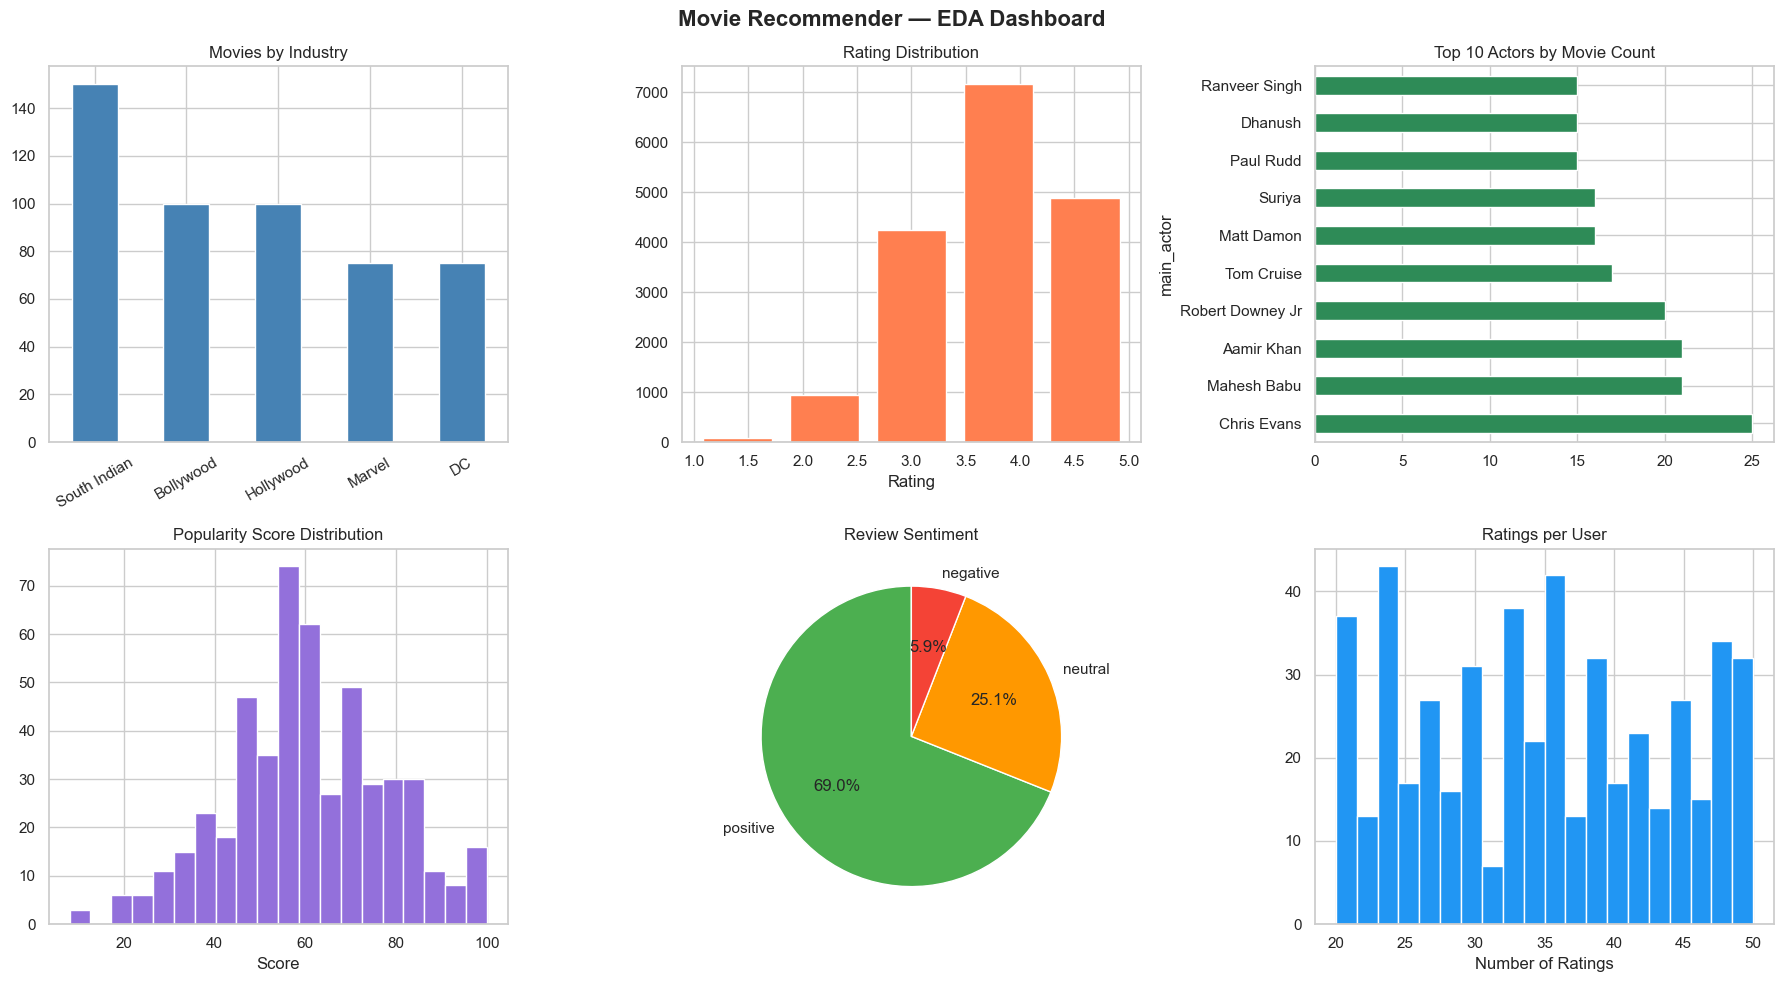

EDA saved to data/eda.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Movie Recommender — EDA Dashboard', fontsize=16, fontweight='bold')

# 1 — Movies by industry
ax = axes[0,0]
movies['industry'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Movies by Industry'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)

# 2 — Rating distribution
ax = axes[0,1]
ratings['rating'].hist(bins=5, ax=ax, color='coral', edgecolor='white', rwidth=0.8)
ax.set_title('Rating Distribution'); ax.set_xlabel('Rating')

# 3 — Top 10 actors by movie count
ax = axes[0,2]
movies['main_actor'].value_counts().head(10).plot(kind='barh', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Top 10 Actors by Movie Count')

# 4 — Popularity distribution
ax = axes[1,0]
movies['popularity_score'].hist(bins=20, ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Popularity Score Distribution'); ax.set_xlabel('Score')

# 5 — Sentiment distribution
ax = axes[1,1]
reviews['sentiment'].value_counts().plot(kind='pie', ax=ax, autopct='%1.1f%%',
    colors=['#4CAF50','#FF9800','#F44336'], startangle=90)
ax.set_title('Review Sentiment'); ax.set_ylabel('')

# 6 — Ratings per user
ax = axes[1,2]
ratings.groupby('user_id').size().hist(bins=20, ax=ax, color='#2196F3', edgecolor='white')
ax.set_title('Ratings per User'); ax.set_xlabel('Number of Ratings')

plt.tight_layout()
plt.savefig(os.path.join(DATA,'eda.png'), dpi=120, bbox_inches='tight')
plt.show()
print('EDA saved to data/eda.png')

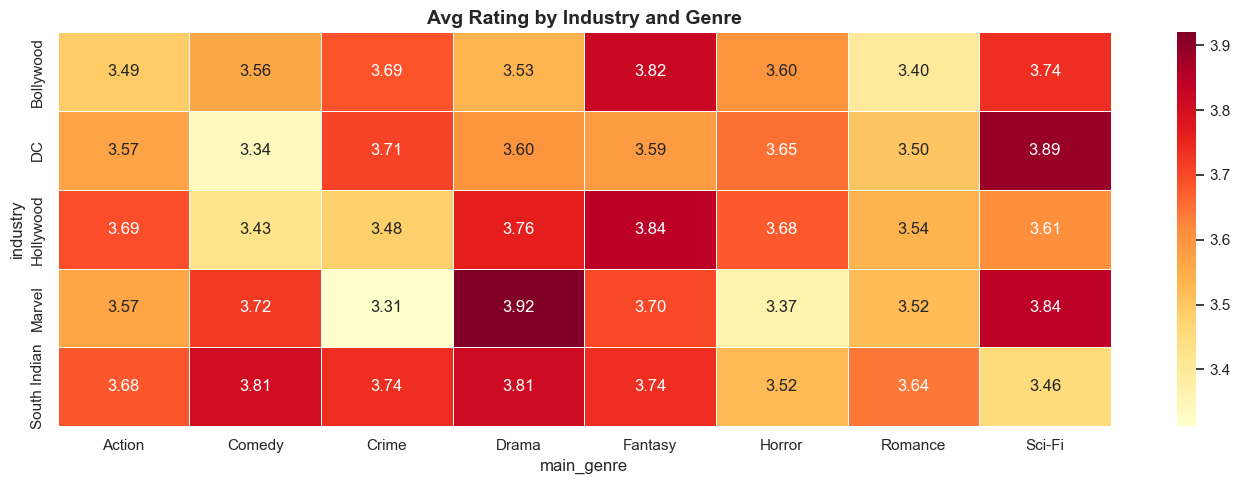

Heatmap saved


In [5]:
# Heatmap — avg rating by industry and genre
movies['main_genre'] = movies['genres'].str.split('|').str[0]
pivot = movies.pivot_table(values='rating_avg', index='industry', columns='main_genre', aggfunc='mean')
plt.figure(figsize=(14,5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Avg Rating by Industry and Genre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA,'heatmap.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Heatmap saved')

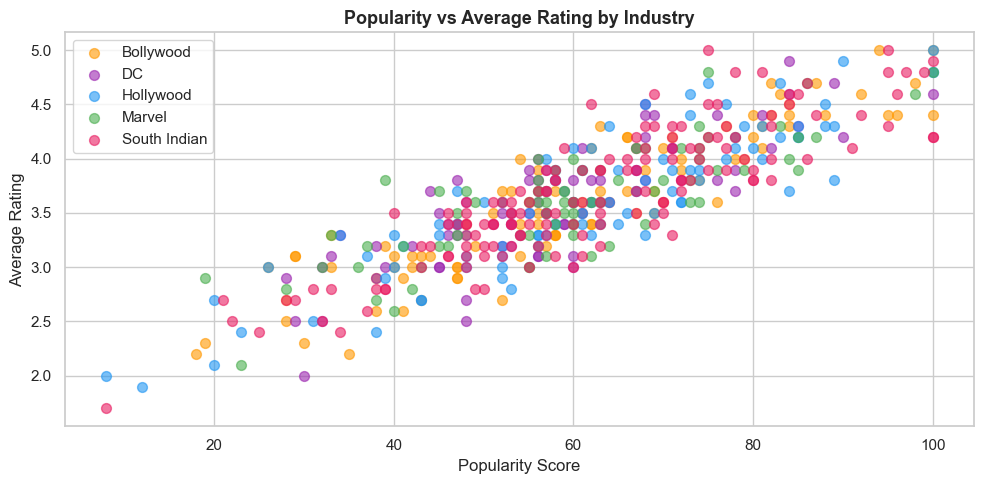

In [6]:
# Popularity vs avg rating scatter
plt.figure(figsize=(10,5))
colors = {'South Indian':'#E91E63','Bollywood':'#FF9800','Hollywood':'#2196F3','Marvel':'#4CAF50','DC':'#9C27B0'}
for ind, grp in movies.groupby('industry'):
    plt.scatter(grp['popularity_score'], grp['rating_avg'], alpha=0.6,
                label=ind, color=colors.get(ind,'gray'), s=50)
plt.xlabel('Popularity Score'); plt.ylabel('Average Rating')
plt.title('Popularity vs Average Rating by Industry', fontsize=13, fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(DATA,'scatter.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. Feature Engineering

In [7]:
# Build content feature string for TF-IDF
movies['content_features'] = (
    movies['genres'].str.replace('|',' ', regex=False) + ' ' +
    movies['main_actor'] + ' ' +
    movies['director'] + ' ' +
    movies['industry'] + ' ' +
    movies['language'] + ' ' +
    movies['description']
)

# Encode user metadata
genre_enc = LabelEncoder()
lang_enc  = LabelEncoder()
users['genre_encoded'] = genre_enc.fit_transform(users['favorite_genre'])
users['lang_encoded']  = lang_enc.fit_transform(users['preferred_language'])

# Merge ratings with movie info
ratings_full = ratings.merge(movies[['movie_id','title','genres','industry','language','popularity_score']], on='movie_id')
ratings_full = ratings_full.merge(users[['user_id','favorite_genre','preferred_language']], on='user_id')

print(f'Content features built for {len(movies)} movies')
print(f'Ratings enriched: {len(ratings_full)} rows')
ratings_full.head(3)

Content features built for 500 movies
Ratings enriched: 17296 rows


,user_id,movie_id,rating,title,genres,industry,language,popularity_score,favorite_genre,preferred_language
0,1,137,5,Kaithi Force,Drama|Romance,South Indian,Telugu,87,Drama,Telugu
1,1,11,5,Julayi 2,Romance|Drama,South Indian,Tamil,96,Drama,Telugu
2,1,12,4,Salaar Returns,Crime|Drama,South Indian,Telugu,58,Drama,Telugu


## 5. Collaborative Filtering (User-User Cosine Similarity)

In [8]:
train_r, test_r = train_test_split(ratings, test_size=0.2, random_state=42)

user_enc = LabelEncoder()
prod_enc = LabelEncoder()
tr = train_r.copy()
tr['u'] = user_enc.fit_transform(tr['user_id'])
tr['p'] = prod_enc.fit_transform(tr['movie_id'])

n_u, n_p = tr['u'].nunique(), tr['p'].nunique()
mat = csr_matrix((tr['rating'], (tr['u'], tr['p'])), shape=(n_u, n_p))
user_sim = cosine_similarity(mat)

print(f'User-item matrix : {mat.shape}')
print(f'Sparsity         : {100*(1-mat.nnz/(n_u*n_p)):.1f}%')
print(f'User similarity  : {user_sim.shape}')

def collab_recommend(user_id, top_n=10):
    if user_id not in user_enc.classes_: return pd.DataFrame()
    u_idx   = user_enc.transform([user_id])[0]
    scores  = user_sim[u_idx] @ mat.toarray()
    already = mat[u_idx].toarray().flatten()
    scores  = scores * (already == 0)
    top_i   = np.argsort(scores)[::-1][:top_n]
    mids    = prod_enc.inverse_transform(top_i)
    return movies[movies.movie_id.isin(mids)][['movie_id','title','industry','genres','main_actor','rating_avg']]

print('\n── CF Recs for User 42 ──')
collab_recommend(42, 5)

User-item matrix : (500, 500)
Sparsity         : 94.5%
User similarity  : (500, 500)

── CF Recs for User 42 ──


,movie_id,title,industry,genres,main_actor,rating_avg
10,11,Julayi 2,South Indian,Romance|Drama,Vijay,4.6
212,213,Animal Unleashed,Bollywood,Romance|Comedy,Shah Rukh Khan,4.7
245,246,Raees War,Bollywood,Comedy|Romance,Ranveer Singh,3.9
368,369,Captain America Legacy,Marvel,Comedy|Romance,Robert Downey Jr,4.3
468,469,Wonder Woman Legacy,DC,Comedy|Romance,Joaquin Phoenix,3.2


## 6. Content-Based Filtering (TF-IDF)

In [9]:
tfidf    = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=5000)
tfidf_m  = tfidf.fit_transform(movies['content_features'])
prod_sim = cosine_similarity(tfidf_m)
mid_to_idx = {mid:i for i,mid in enumerate(movies['movie_id'])}

def content_recommend(movie_id, top_n=10):
    if movie_id not in mid_to_idx: return pd.DataFrame()
    idx    = mid_to_idx[movie_id]
    scores = sorted(enumerate(prod_sim[idx]), key=lambda x:x[1], reverse=True)
    top    = movies.iloc[[i for i,_ in scores[1:top_n+1]]]
    return top[['movie_id','title','industry','genres','main_actor','rating_avg']]

sample_movie = movies.iloc[0]
print(f'── Similar to: {sample_movie["title"]} ──')
content_recommend(sample_movie['movie_id'], 5)

── Similar to: Pushpa 2  ──


,movie_id,title,industry,genres,main_actor,rating_avg
79,80,Mirchi 2,South Indian,Fantasy|Drama,Prabhas,3.4
115,116,Julayi Unleashed,South Indian,Fantasy|Drama,Suriya,3.2
26,27,Vikram 3,South Indian,Fantasy|Adventure,Prabhas,3.6
350,351,Black Panther Returns,Marvel,Fantasy|Action,Chris Hemsworth,3.5
88,89,Srimanthudu Rising,South Indian,Fantasy|Adventure,Ajith Kumar,3.9


## 7. Hybrid Recommender

In [10]:
def hybrid_recommend(user_id, top_n=10, alpha=0.6):
    cf = collab_recommend(user_id, top_n*2)
    u_movies = ratings[ratings.user_id==user_id]
    if u_movies.empty or cf.empty: return cf.head(top_n)

    last_mid = u_movies.sort_values('movie_id').iloc[-1]['movie_id']
    cb = content_recommend(last_mid, top_n*2)

    cf_ids = cf['movie_id'].tolist()
    cb_ids = cb['movie_id'].tolist()
    all_ids = list(dict.fromkeys(cf_ids + cb_ids))

    cf_score = {mid:(len(cf_ids)-i)*alpha     for i,mid in enumerate(cf_ids)}
    cb_score = {mid:(len(cb_ids)-i)*(1-alpha) for i,mid in enumerate(cb_ids)}
    combined = {mid: cf_score.get(mid,0)+cb_score.get(mid,0) for mid in all_ids}
    top_ids  = sorted(combined, key=combined.get, reverse=True)[:top_n]
    return movies[movies.movie_id.isin(top_ids)][['movie_id','title','industry','genres','main_actor','rating_avg']]

print('── Hybrid Recs for User 10 ──')
hybrid_recommend(10, 8)

── Hybrid Recs for User 10 ──


,movie_id,title,industry,genres,main_actor,rating_avg
68,69,Vettai War,South Indian,Sci-Fi|Thriller,Vijay,3.4
99,100,Leo Legacy,South Indian,Sci-Fi|Fantasy,Allu Arjun,3.6
116,117,Duvvada Reborn,South Indian,Sci-Fi|Fantasy,Vikram,3.3
166,167,Sanju 2,Bollywood,Sci-Fi|Adventure,Ranbir Kapoor,3.3
187,188,Kick Storm,Bollywood,Sci-Fi|Thriller,Ranveer Singh,4.4
202,203,Rockstar Storm,Bollywood,Sci-Fi|Fantasy,Aamir Khan,3.4
210,211,Rockstar Force,Bollywood,Sci-Fi|Action,Aamir Khan,5.0
307,308,Wolf War,Hollywood,Action|Thriller,Matt Damon,4.8


## 8. Evaluation — Precision / Recall / NDCG @ K

── Evaluation Results ──
  Precision@10: 0.0700
  Recall@10: 0.0899
  NDCG@10: 0.0830


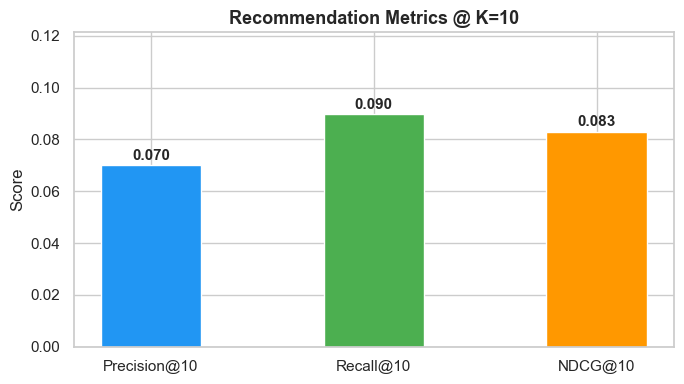

In [11]:
def precision_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / k if k else 0
def recall_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / len(rel) if rel else 0
def ndcg_at_k(rec, rel, k):
    dcg  = sum(1/np.log2(i+2) for i,p in enumerate(rec[:k]) if p in rel)
    idcg = sum(1/np.log2(i+2) for i in range(min(len(rel),k)))
    return dcg/idcg if idcg else 0

K = 10
p_s, r_s, n_s = [], [], []
for uid in test_r['user_id'].unique()[:100]:
    rel = test_r[test_r.user_id==uid]['movie_id'].tolist()
    if not rel: continue
    recs_df  = collab_recommend(uid, K)
    rec_mids = recs_df['movie_id'].tolist()
    p_s.append(precision_at_k(rec_mids, rel, K))
    r_s.append(recall_at_k(rec_mids, rel, K))
    n_s.append(ndcg_at_k(rec_mids, rel, K))

results = {f'Precision@{K}':np.mean(p_s), f'Recall@{K}':np.mean(r_s), f'NDCG@{K}':np.mean(n_s)}
print('── Evaluation Results ──')
for k,v in results.items(): print(f'  {k}: {v:.4f}')

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(results.keys(), results.values(),
              color=['#2196F3','#4CAF50','#FF9800'], width=0.45, edgecolor='white')
for b,v in zip(bars,results.values()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
            f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(results.values())*1.35)
ax.set_title(f'Recommendation Metrics @ K={K}', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig(os.path.join(DATA,'metrics.png'), dpi=120, bbox_inches='tight')
plt.show()

## 9. Save Models

In [12]:
pickle.dump({'user_sim':user_sim,'mat':mat,'user_enc':user_enc,'prod_enc':prod_enc},
            open(os.path.join(MODELS,'collab_model.pkl'),'wb'))
pickle.dump({'prod_sim':prod_sim,'mid_to_idx':mid_to_idx,'tfidf':tfidf},
            open(os.path.join(MODELS,'content_model.pkl'),'wb'))

print('Models saved!')
print(f'  {MODELS}/collab_model.pkl')
print(f'  {MODELS}/content_model.pkl')
print('\nRun: streamlit run app/streamlit_app.py')
print('Run: uvicorn app.main:app --reload')

Models saved!
  /Users/sai/Desktop/cherryflix/models/collab_model.pkl
  /Users/sai/Desktop/cherryflix/models/content_model.pkl

Run: streamlit run app/streamlit_app.py
Run: uvicorn app.main:app --reload
